# 07 — Benefits Landscape

What benefits German IT employers offer and how they vary by role. Analyses the prevalence of benefit categories across the dataset, how they differ by job family, and which employers are most generous.

In [1]:
from analysis.utils import notebook_init

df = notebook_init()

Loaded 19,148 rows × 29 columns


In [2]:
from analysis import charts as _charts
from analysis.charts import horizontal_bar, heatmap, stacked_bar
from analysis.filters import explode_json_col

df.head(3)

,row_id,job_url,date_posted,company_name,city,state,title,title_cleaned,job_family,job_summary,...,nice_to_have_skills,benefits,tasks,languages,benefit_categories,soft_skill_categories,description_quality,site,validation_flags,description
0,c3b86e465187,https://de.linkedin.com/jobs/view/softwareentw...,2025-11-17,HMS Analytical Software | Consulting & End-to-...,Heidelberg,Baden-Württemberg,Softwareentwickler / Data Engineer DevOps (mwd),Software Developer / Data Engineer DevOps,Data Engineer,Software Developer / Data Engineer DevOps crea...,...,"[""AWS"", ""Azure"", ""Scripting Languages""]","[""Flexible working hours"", ""Mobile Office / hy...","[""Create, extend and operate innovative, perfo...",[],"[""compensation"", ""education"", ""flexible_hours""...","[""Communication"", ""Customer Focus"", ""Teamwork""]",concatenated,linkedin,[],Unsere über 30-jährige Erfolgsgeschichte im So...
1,a85937eee245,https://de.linkedin.com/jobs/view/werkstudent-...,2025-12-17,HMS Analytical Software | Consulting & End-to-...,Heidelberg,Baden-Württemberg,"Werkstudent (mwd) Data Analytics, BI & Reporting","Working Student Data Analytics, BI & Reporting",Working Student,"Working student supporting data analytics, BI,...",...,"[""MS PowerBI""]","[""Flexible working hours"", ""Mobile Office/hybr...","[""Building and maintaining modern data pipelin...",[],"[""education"", ""flexible_hours"", ""food"", ""healt...","[""Teamwork""]",concatenated,linkedin,"[{""field"": ""contract_type"", ""rule"": ""intern_co...",Unsere über 35-jährige Erfolgsgeschichte im So...
2,afa0059eab62,https://de.linkedin.com/jobs/view/system-admin...,2026-01-16,NZR Nordwestdeutsche Zählerrevision Ing. Aug. ...,Bad Laer,Lower Saxony,System-Administrator (m/w/d),System-Administrator,System Administrator,System administrator responsible for maintaini...,...,"[""InforCom ERP""]","[""29 vacation days"", ""Flexible working hours"",...","[""Ensuring smooth IT operations across entire ...",[],"[""education"", ""flexible_hours"", ""health"", ""mob...","[""Structured Work"", ""Teamwork""]",concatenated,linkedin,"[{""field"": ""technical_skills"", ""rule"": ""skill_...",Ihre Vorteile bei NZR:Ein attraktives Gehalt i...


## Top Benefit Categories

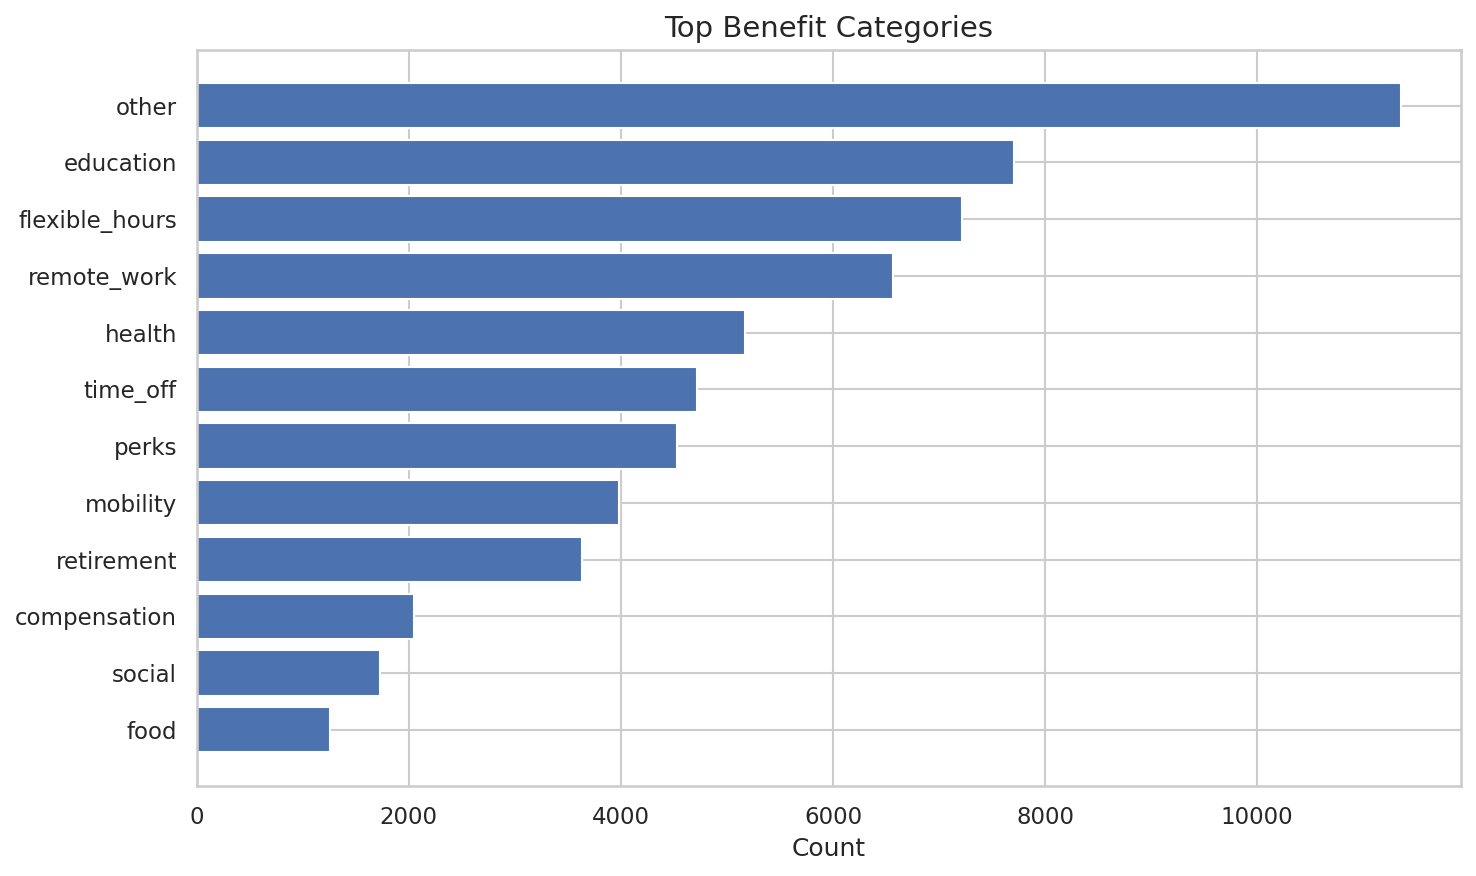

In [3]:
benefit_cats_exploded = explode_json_col(df, "benefit_categories")
horizontal_bar(
    benefit_cats_exploded["benefit_categories"],
    "Top Benefit Categories",
    save_as="07_benefits.png",
)

## Benefit Categories x Job Family Heatmap

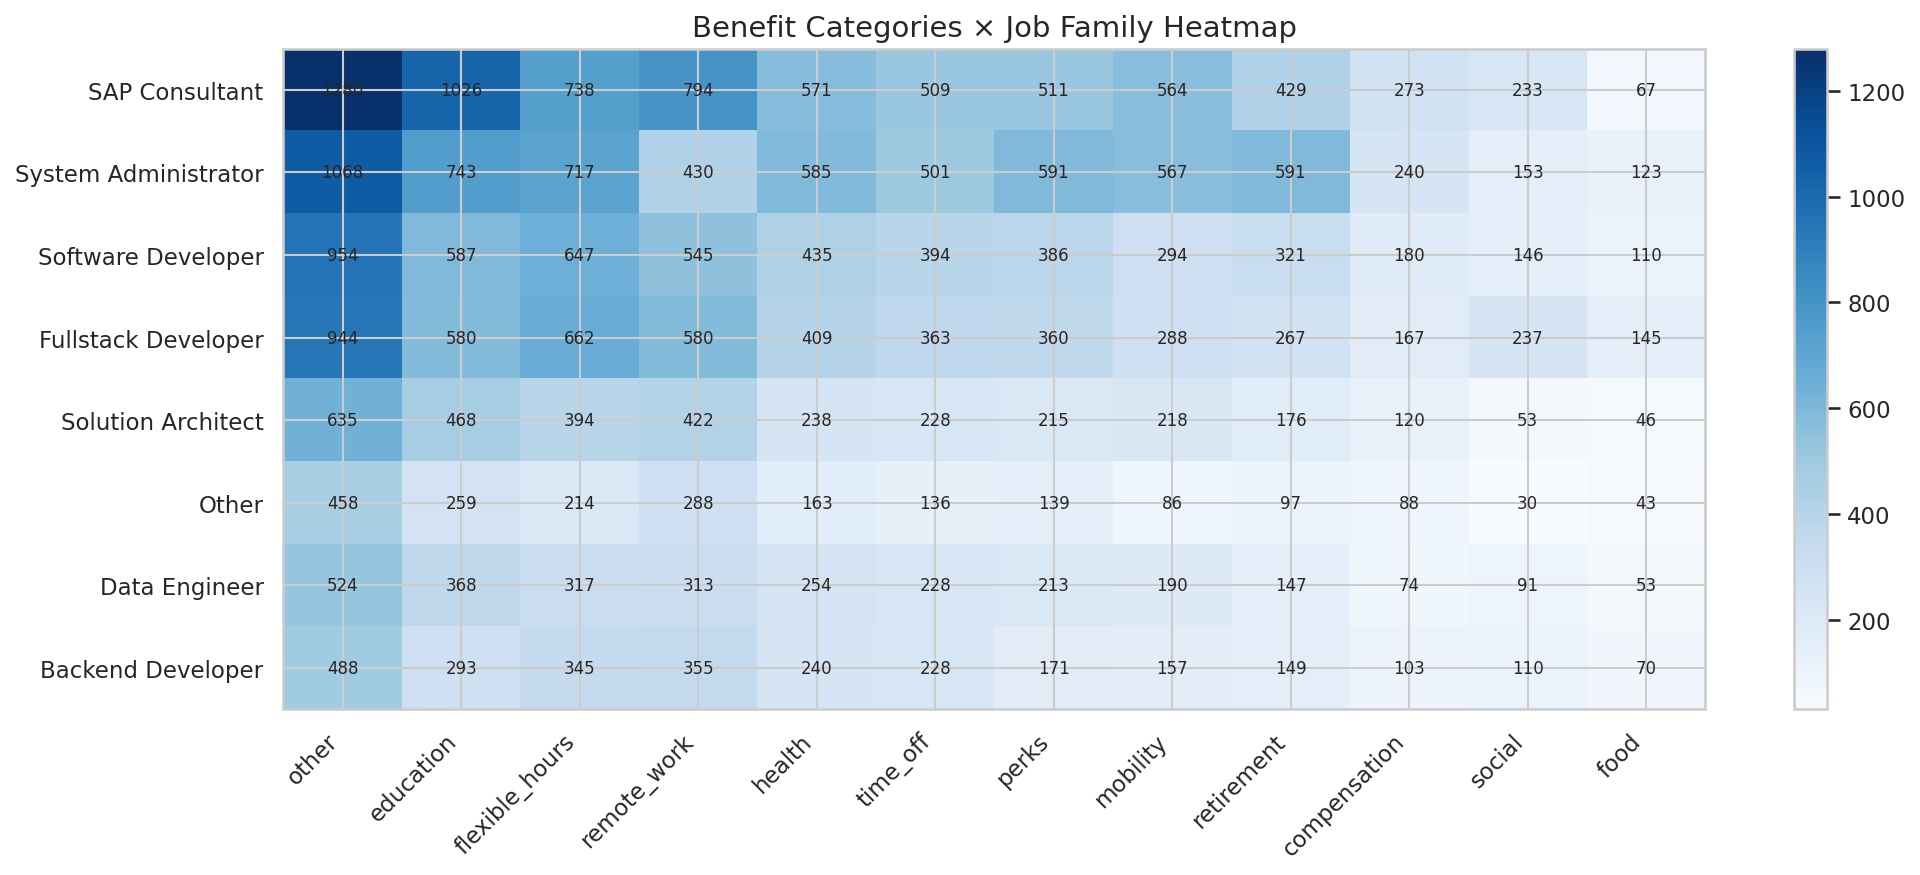

In [4]:
import pandas as pd

top_families = df["job_family"].value_counts().head(8).index
all_cats = benefit_cats_exploded["benefit_categories"].value_counts().index.tolist()

pivot = (
    benefit_cats_exploded[benefit_cats_exploded["job_family"].isin(top_families)]
    .groupby(["job_family", "benefit_categories"])
    .size()
    .unstack(fill_value=0)
)
pivot = pivot.reindex(index=top_families, columns=all_cats, fill_value=0)
heatmap(pivot, "Benefit Categories × Job Family Heatmap", figsize=(14, 6), save_as="07_benefit_family.png")

## Urlaub (30+ days) Prevalence

Urlaub/vacation mentioned: 3,689 / 19,148 (19.3%)


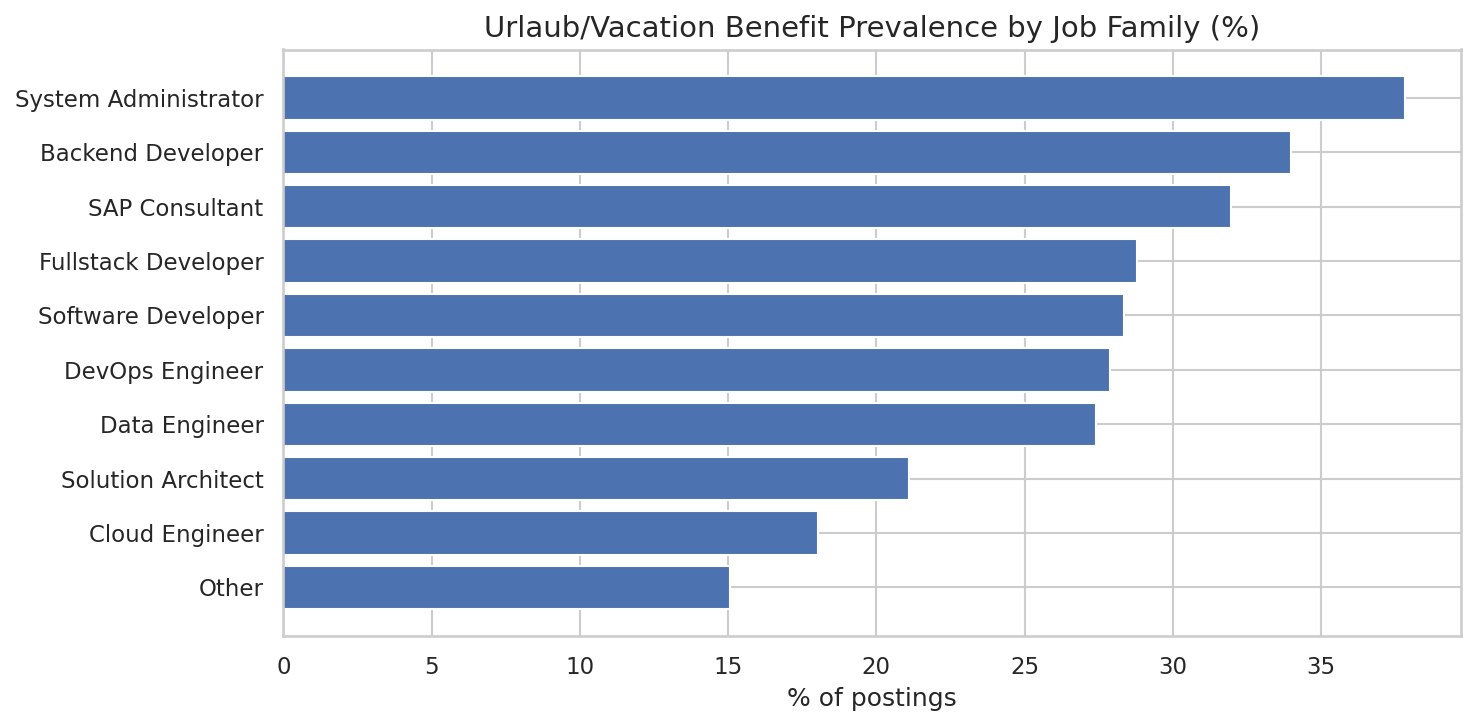

In [5]:
import json

def has_urlaub(benefits_json: object) -> bool:
    try:
        benefits = json.loads(str(benefits_json))
        return any(
            isinstance(b, str) and ("urlaub" in b.lower() or "vacation" in b.lower())
            for b in benefits
        )
    except (json.JSONDecodeError, TypeError):
        return False

urlaub_count = df["benefits"].apply(has_urlaub).sum()
total = len(df)
print(f"Urlaub/vacation mentioned: {urlaub_count:,} / {total:,} ({urlaub_count/total*100:.1f}%)")

# Breakdown by job family
import matplotlib.pyplot as plt
df2 = df.copy()
df2["has_urlaub"] = df2["benefits"].apply(has_urlaub)
top_families = df2["job_family"].value_counts().head(10).index
family_pct = (
    df2[df2["job_family"].isin(top_families)]
    .groupby("job_family")["has_urlaub"]
    .mean()
    .sort_values()
    * 100
)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(family_pct.index, family_pct.values)
ax.set_title("Urlaub/Vacation Benefit Prevalence by Job Family (%)")
ax.set_xlabel("% of postings")
plt.tight_layout()
if _charts.FIGURES_DIR:
    fig.savefig(_charts.FIGURES_DIR / "07_urlaub_family.png", dpi=150)

## Top Companies by Benefit Count

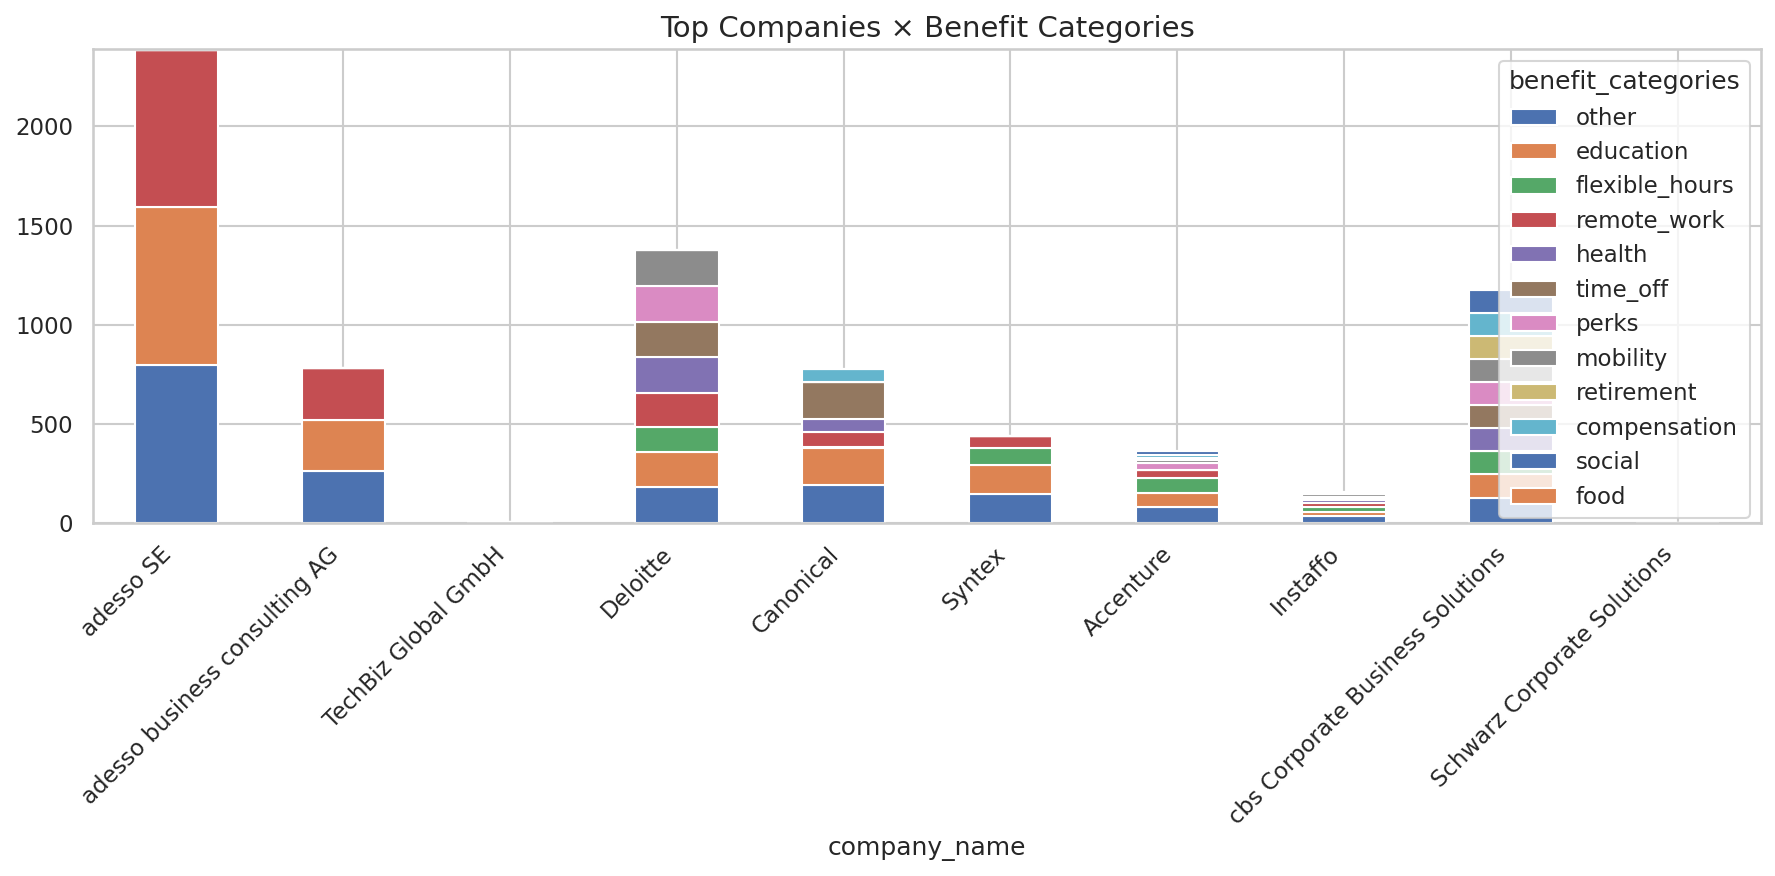

In [6]:
top_companies = df[df["company_name"].notna()]["company_name"].value_counts().head(10).index
all_benefit_cats = benefit_cats_exploded["benefit_categories"].value_counts().index.tolist()

company_pivot = (
    benefit_cats_exploded[benefit_cats_exploded["company_name"].isin(top_companies)]
    .groupby(["company_name", "benefit_categories"])
    .size()
    .unstack(fill_value=0)
)
company_pivot = company_pivot.reindex(index=top_companies, columns=all_benefit_cats, fill_value=0)
stacked_bar(company_pivot, "Top Companies × Benefit Categories", save_as="07_company_benefits.png")